In [6]:
import pandas as pd
import numpy as np

DATA_FILE = '../data/scenario_6_marina_features_50ms_final.csv'
df = pd.read_csv(DATA_FILE)

df.sort_values(['video_id', 'iteration', 'timestamp'], inplace=True)

print("Generating Advanced Network Features...")

#we don't calculate trends across different video sessions
g = df.groupby(['video_id', 'iteration'])

# Exponential Moving Averages (EMA) 
# Simulates the switch keeping a 'running average' state
# span=20 roughly equals 1 second of history (20 * 50ms)
df['bw_ema'] = g['bwe'].transform(lambda x: x.ewm(span=20, adjust=False).mean())
df['jitter_ema'] = g['jitter'].transform(lambda x: x.ewm(span=20, adjust=False).mean())
df['iat_ema'] = g['iat_sum'].transform(lambda x: x.ewm(span=20, adjust=False).mean())

#  Lag Features (What happened 50ms ago?)
cols_to_lag = ['bwe', 'jitter', 'packet_count']
for col in cols_to_lag:
    df[f'{col}_prev'] = g[col].shift(1) # 1 step back

#Rate of Change (Acceleration) 
# Is bandwidth dropping fast?
df['bw_change'] = df['bwe'] - df['bwe_prev']

df.dropna(inplace=True)

print(f"Feature Engineering Complete. Final Shape: {df.shape}")
df.head()

Generating Advanced Network Features...
Feature Engineering Complete. Final Shape: (163039, 20)


,timestamp,packet_count,ps_sum,ps2_sum,ps3_sum,iat_sum,iat2_sum,iat3_sum,jitter,buffer_level_ms,bwe,video_id,iteration,bw_ema,jitter_ema,iat_ema,bwe_prev,jitter_prev,packet_count_prev,bw_change
1,1517451593950,73,67845,91262479,125607724845,50.209046,59.186920,97.430733,0.674682,11729,11491117,Vid_2d1VrCvdzbY,Iteration_1,11491117.0,0.593326,50.108523,11491117.0,0.584762,82.0,0.0
2,1517451594000,69,66253,89348217,122989949167,50.037145,54.620074,72.432084,0.694607,11729,11491117,Vid_2d1VrCvdzbY,Iteration_1,11491117.0,0.602972,50.101725,11491117.0,0.674682,73.0,0.0
3,1517451594050,71,66387,89357195,122990550693,49.897909,64.854621,116.702641,0.712479,11729,11491117,Vid_2d1VrCvdzbY,Iteration_1,11491117.0,0.613401,50.082314,11491117.0,0.694607,69.0,0.0
4,1517451594100,71,66387,89357195,122990550693,48.899889,53.711902,72.957715,0.648478,11729,11491117,Vid_2d1VrCvdzbY,Iteration_1,11491117.0,0.616742,49.969702,11491117.0,0.712479,71.0,0.0
5,1517451594900,72,67765,91256079,125607212845,50.486087,52.013690,66.979565,0.613309,11729,11491117,Vid_2d1VrCvdzbY,Iteration_1,11491117.0,0.616415,50.018882,11491117.0,0.648478,71.0,0.0


In [7]:
LOOKAHEAD_STEPS = 10       # Look 500ms into the future
DROP_THRESHOLD = -200      # Buffer dropping by > 200ms

# Calculate future slope
df['future_buffer'] = df.groupby(['video_id', 'iteration'])['buffer_level_ms'].shift(-LOOKAHEAD_STEPS)
df['buffer_slope'] = df['future_buffer'] - df['buffer_level_ms']

df.dropna(subset=['future_buffer'], inplace=True)

# Binary label: At_Risk if buffer is dropping significantly, Steady otherwise
df['qoe_state'] = np.where(
    (df['buffer_slope'] < DROP_THRESHOLD),
    'At_Risk',
    'Steady'
)

print("Target Class Distribution:")
print(df['qoe_state'].value_counts(normalize=True))

Target Class Distribution:
qoe_state
At_Risk    0.613367
Steady     0.386633
Name: proportion, dtype: float64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


features = [
    # Instant values
    'packet_count', 'ps_sum', 'ps2_sum', 'ps3_sum', 
    'iat_sum', 'iat2_sum', 'iat3_sum',
    'jitter',
    # Historical Context 
    #'bw_ema',
    #'jitter_ema', 'iat_ema',
    #'bwe_prev', 
    #'jitter_prev',
    #'bw_change',
]

X = df[features]
y = df['qoe_state']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12, 
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Training Random Forest...

--- Classification Report ---
              precision    recall  f1-score   support

     At_Risk       0.80      0.80      0.80     24923
      Steady       0.69      0.69      0.69     15710

    accuracy                           0.76     40633
   macro avg       0.75      0.75      0.75     40633
weighted avg       0.76      0.76      0.76     40633



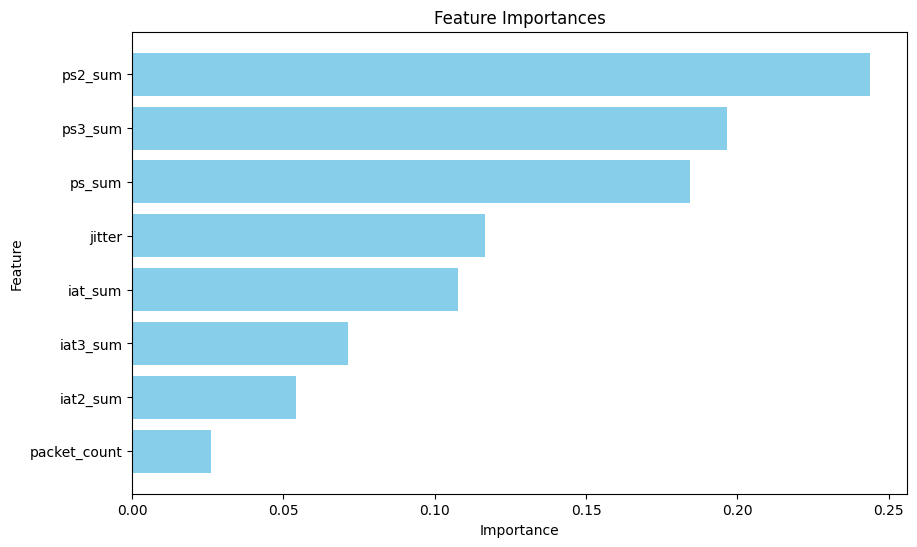

        Feature  Importance
2       ps2_sum    0.243863
3       ps3_sum    0.196520
1        ps_sum    0.184213
7        jitter    0.116552
4       iat_sum    0.107743
6      iat3_sum    0.071238
5      iat2_sum    0.053972
0  packet_count    0.025899


In [9]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_

feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.gca().invert_yaxis()
plt.show()

print(feature_importances)

In [10]:
print("X", X.shape)
print("X", X.head())
np.save('np_data.npy', X.to_numpy())

y_dummies = pd.get_dummies(y)
np.save('np_dummies.npy', y_dummies.to_numpy())

print("Files 'np_data.npy' and 'np_dummies.npy' have been created.")

X (162529, 8)
X    packet_count  ps_sum   ps2_sum       ps3_sum    iat_sum   iat2_sum  \
1            73   67845  91262479  125607724845  50.209046  59.186920   
2            69   66253  89348217  122989949167  50.037145  54.620074   
3            71   66387  89357195  122990550693  49.897909  64.854621   
4            71   66387  89357195  122990550693  48.899889  53.711902   
5            72   67765  91256079  125607212845  50.486087  52.013690   

     iat3_sum    jitter  
1   97.430733  0.674682  
2   72.432084  0.694607  
3  116.702641  0.712479  
4   72.957715  0.648478  
5   66.979565  0.613309  
Files 'np_data.npy' and 'np_dummies.npy' have been created.


## TODO Implement a graph/excalidraw/diagram showing the difference between isolated window features vs lagged features and EMA features.
Lag feature
Our previous model looks at a single 50ms window in isolation. However, the Buffer Level is cumulative. If the throughput was low 1 second ago, the buffer is likely suffering now, even if the current 50ms window looks fine.

Capture "ON/OFF" Burst Patterns
The Problem: Video traffic is not constant; it comes in bursts (ON periods) followed by silence (OFF periods).

Maybe Create features that specifically measure the "Silence"?

## Use "Rolling" Statistics (Trend Analysis)
50ms is noisy. One dropped packet causes a spike in Jitter that might not mean anything.
Exponential Moving Averages (EMA). Switches can calculate EMA efficiently because it only requires storing the previous value.
EMA_t = α * X_t + (1 - α) * EMA_(t-1)
Where:
- EMA_t is the current EMA value.
- X_t is the current observation.
- α is the smoothing factor (0 < α ≤ 1), which determines how much weight is given to the most recent observation versus the historical EMA.
By incorporating EMA features for Throughput and Jitter over a 1-second horizon, the model can better capture underlying trends rather than reacting to transient spikes or drops.


These two variables have been calcucalted in the control plane rather than the data plane, as they require division operations which are more computationally expensive. However, they could be approximated in the data plane using fixed-point arithmetic or lookup tables if necessary for real-time processing.